# Projekt MAPB - Milestone 3: modele procesu (Cotton Candy)

Notebook przygotowuje modele procesu wymagane w Milestone 3 na podstawie pracy wykonanej w Milestone 1 i Milestone 2.

Zakres:
- sprawdzenie, czy mamy model referencyjny,
- model odkryty z workflow logu XES/YAML,
- DFG (Directly-Follows Graph),
- co najmniej dwa algorytmy odkrywania procesu dla workflow logu,
- model odkryty z klasteryzacji danych IoT/sensorowych,
- interpretacja klastrów IoT i ich przejść,
- porównanie modeli oraz wnioski procesowe.

Uwaga: w Milestone 1 nie znaleziono gotowego BPMN/XML modelu referencyjnego w danych, więc w tym notebooku część referencyjna jest jawnie oznaczona jako niedostępna dla naszego przypadku.

In [103]:
# Podstawowe importy
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse
import math
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Importy opcjonalne - notebook ma fallbacki, ale PM4Py daje właściwe modele process mining.
try:
    import yaml
    HAS_YAML = True
except Exception as e:
    HAS_YAML = False
    print("Brak PyYAML. Zainstaluj: pip install pyyaml")

try:
    import pm4py
    HAS_PM4PY = True
except Exception as e:
    HAS_PM4PY = False
    print("Brak PM4Py. Modele process mining będą pominięte; zainstaluj: pip install pm4py")

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans, DBSCAN
    from sklearn.metrics import silhouette_score
    from sklearn.decomposition import PCA
    HAS_SKLEARN = True
except Exception as e:
    HAS_SKLEARN = False
    print("Brak scikit-learn. Klasteryzacja IoT wymaga: pip install scikit-learn")

try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False
    print("Brak umap-learn. Użyję PCA jako fallback dla DBSCAN, jeśli sklearn jest dostępny.")

In [104]:
# Diagnostyka kernela i instalacja PM4Py do aktywnego środowiska notebooka
import sys

print("Python używany przez ten notebook:")
print(sys.executable)

try:
    import pm4py
    print("PM4Py jest dostępne:", pm4py.__version__)
except ImportError:
    print("PM4Py nie jest dostępne w tym kernelu. Instaluję do aktywnego środowiska...")
    !{sys.executable} -m pip install pm4py
    print("Po instalacji zrestartuj kernel i uruchom notebook od początku.")


Python używany przez ten notebook:
/opt/miniconda3/envs/base1/bin/python
PM4Py jest dostępne: 2.7.22.4


In [105]:
# Diagnostyka Graphviz dla wizualizacji PM4Py
import shutil

DOT_PATH = shutil.which("dot")
if DOT_PATH:
    print("Graphviz dot jest dostępny:", DOT_PATH)
else:
    print("Brak Graphviz dot w PATH.")
    print("Modele BPMN/PNML mogą się zapisać, ale PNG z PM4Py nie powstaną bez Graphviz.")
    print("macOS/Homebrew: brew install graphviz")
    print("Conda: conda install -c conda-forge graphviz python-graphviz")


Graphviz dot jest dostępny: /opt/miniconda3/envs/base1/bin/dot


In [106]:
# Helper do pokazywania wygenerowanych modeli bezpośrednio w notebooku
def show_model_image(path, title, description):
    path = Path(path)
    display(Markdown(f"### {title}"))
    display(Markdown(description))
    if path.exists():
        display(Image(filename=str(path)))
        print("Plik:", path)
    else:
        print("Nie znaleziono pliku obrazu:", path)
        print("Jeśli to wizualizacja PM4Py, sprawdź czy Graphviz dot jest dostępny i uruchom komórkę modelu ponownie.")


In [107]:
# Ścieżka do danych - zgodnie z notebookami Milestone 1/2, ale z fallbackami dla różnych komputerów
candidate_base_dirs = [
    Path(r"/Users/kacperciesla/Documents/Studia/MiAPB"),
    Path(r"C:/Users/dusza/Documents/Studia/7semestr/MAPB"),
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.cwd().resolve().parent.parent,
]

BASE_DIR = next((p for p in candidate_base_dirs if (p / "cotton-candy").exists()), candidate_base_dirs[0])
DATA_DIR = BASE_DIR / "cotton-candy"

# Jeśli auto-detekcja nie trafi, ustaw ręcznie, np.:
# DATA_DIR = Path(r"/pełna/ścieżka/do/cotton-candy")

# Katalog na artefakty Milestone 3
REPORT_DIR = Path("reports/milestone3")
FIG_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Katalog danych:", DATA_DIR)
print("Katalog artefaktów:", REPORT_DIR.resolve())
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Nie znaleziono katalogu danych: {DATA_DIR}. "
        "Ustaw DATA_DIR ręcznie na katalog cotton-candy."
    )

xes_files = sorted(DATA_DIR.glob("batch-*/*.xes.yaml"))
process_files = sorted(DATA_DIR.glob("batch-*/*-process.yaml"))
print(f"Liczba plików *.xes.yaml: {len(xes_files)}")
print(f"Liczba plików *-process.yaml: {len(process_files)}")

if len(xes_files) == 0:
    raise FileNotFoundError(
        f"W katalogu {DATA_DIR} nie znaleziono plików batch-*/*.xes.yaml. "
        "Sprawdź, czy DATA_DIR wskazuje bezpośrednio na folder cotton-candy."
    )

Katalog danych: /Users/kacperciesla/Documents/Studia/MiAPB/cotton-candy
Katalog artefaktów: /Users/kacperciesla/Documents/Studia/MiAPB/MAPB/reports/milestone3
Liczba plików *.xes.yaml: 1294
Liczba plików *-process.yaml: 33


## 1. Model referencyjny

W Milestone 1 sprawdzaliśmy, czy w danych znajduje się gotowy model BPMN/XML. Dla naszego przypadku nie znaleźliśmy gotowego modelu referencyjnego procesu. Dlatego w Milestone 3 nie wizualizujemy modelu referencyjnego i skupiamy się na dwóch modelach dostępnych dla danych:

1. modelu odkrytym z workflow logu, gdzie aktywności są nazwane przez `concept:name`,
2. modelu odkrytym na podstawie klasteryzacji danych IoT/sensorowych, gdzie aktywnością staje się przypisany i zinterpretowany klaster.

## 2. Wczytanie i czyszczenie workflow logu

Kod bazuje na parserze z Milestone 2. Z logów `*.xes.yaml` pobieramy case id, activity, timestamp, endpoint/resource i lifecycle. Następnie usuwamy duplikaty oraz zdarzenia bez poprawnego timestampa.

In [108]:
INTEREST_KEYS = {
    "concept:instance", "cpee:instance", "concept:name",
    "time:timestamp", "concept:endpoint", "id:id",
    "cpee:activity", "lifecycle:transition", "cpee:lifecycle:transition",
}

def stream_events_fast(file_path):
    """Szybki parser liniowy eventów XES zapisanych jako YAML."""
    current = None
    seq = 0
    with file_path.open("r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")
            if line == "---":
                if current is not None:
                    yield current, seq
                current = None
                continue
            if line == "event:":
                current = {}
                seq += 1
                continue
            if current is None:
                continue
            if line.startswith("  ") and not line.startswith("    "):
                stripped = line.strip()
                if ": " in stripped:
                    key, value = stripped.split(": ", 1)
                elif stripped.endswith(":"):
                    key, value = stripped[:-1], ""
                else:
                    continue
                if key in INTEREST_KEYS and key not in current:
                    current[key] = value.strip("'\"")
    if current is not None:
        yield current, seq

def stream_events_yaml(file_path):
    """Wolniejszy, ale odporniejszy fallback przez PyYAML."""
    if not HAS_YAML:
        return
    with file_path.open("r", encoding="utf-8") as f:
        for seq, doc in enumerate(yaml.safe_load_all(f), start=1):
            if isinstance(doc, dict) and isinstance(doc.get("event"), dict):
                yield doc["event"], seq

def events_from_file(file_path):
    events = list(stream_events_fast(file_path))
    if events:
        return events
    return list(stream_events_yaml(file_path))

def normalize_resource(endpoint):
    if endpoint is None or pd.isna(endpoint):
        return None
    endpoint = str(endpoint).strip()
    if not endpoint:
        return None
    endpoint = endpoint.replace("https-get://", "https://").replace("https-post://", "https://")
    parsed = urlparse(endpoint)
    return parsed.netloc if parsed.netloc else endpoint

rows = []
empty_files = 0
for i, path in enumerate(xes_files, start=1):
    batch_name = path.parent.name
    file_id = str(path.relative_to(DATA_DIR)).replace("\\", "/")
    file_events = events_from_file(path)
    if not file_events:
        empty_files += 1
    for event, seq in file_events:
        rows.append({
            "batch": batch_name,
            "file": file_id,
            "case_id": event.get("cpee:instance") or event.get("concept:instance") or file_id,
            "concept_instance": event.get("concept:instance"),
            "activity": event.get("concept:name") or event.get("id:id") or event.get("cpee:activity"),
            "timestamp_raw": event.get("time:timestamp"),
            "endpoint": event.get("concept:endpoint"),
            "lifecycle": event.get("lifecycle:transition"),
            "cpee_lifecycle": event.get("cpee:lifecycle:transition"),
            "seq": seq,
        })
    if i % 200 == 0:
        print(f"Przetworzono {i}/{len(xes_files)} plików, zdarzeń: {len(rows):,}")

if not rows:
    raise ValueError(
        "Nie wczytano żadnych zdarzeń z plików *.xes.yaml. "
        "Sprawdź DATA_DIR oraz instalację PyYAML; szybki parser i fallback YAML zwróciły pusty wynik."
    )
if empty_files:
    print(f"Uwaga: {empty_files} plików nie zwróciło eventów.")

df_raw = pd.DataFrame(rows)
print(f"Wczytano {len(df_raw):,} zdarzeń z {df_raw['case_id'].nunique():,} przypadków")

df = df_raw.copy()
df["timestamp"] = pd.to_datetime(df["timestamp_raw"], errors="coerce", utc=True)
df["activity_clean"] = df["activity"].astype(str).str.strip()
df.loc[df["activity_clean"].isin(["", "None", "nan", "NaN"]), "activity_clean"] = np.nan
df["resource"] = df["endpoint"].map(normalize_resource)

before = len(df)
dedup_cols = ["case_id", "activity_clean", "timestamp_raw", "endpoint", "lifecycle", "cpee_lifecycle"]
df = df.drop_duplicates(subset=dedup_cols).copy()
removed_dups = before - len(df)
missing_ts = int(df["timestamp"].isna().sum())
df = df.dropna(subset=["timestamp", "activity_clean"]).copy()
df = df.sort_values(["case_id", "timestamp", "seq"]).reset_index(drop=True)

print(f"Usunięte duplikaty: {removed_dups:,}")
print(f"Zdarzenia bez timestampa po deduplikacji: {missing_ts:,}")
print(f"Po czyszczeniu: {len(df):,} zdarzeń, {df['case_id'].nunique():,} przypadków, {df['activity_clean'].nunique():,} aktywności")

Przetworzono 200/1294 plików, zdarzeń: 70,113
Przetworzono 400/1294 plików, zdarzeń: 149,549
Przetworzono 600/1294 plików, zdarzeń: 258,503
Przetworzono 800/1294 plików, zdarzeń: 347,549
Przetworzono 1000/1294 plików, zdarzeń: 438,885
Przetworzono 1200/1294 plików, zdarzeń: 526,361
Wczytano 564,185 zdarzeń z 1,244 przypadków
Usunięte duplikaty: 99,812
Zdarzenia bez timestampa po deduplikacji: 871
Po czyszczeniu: 463,502 zdarzeń, 1,244 przypadków, 64 aktywności


## 3. Directly-Follows Graph z workflow logu

DFG pokazuje, które aktywności bezpośrednio następowały po sobie. W naszym logu najczęstsze przejścia są zdominowane przez powtarzalne pobieranie danych środowiskowych i danych z wtyczki zasilającej.

In [109]:
df_sorted = df.sort_values(["case_id", "timestamp", "seq"]).copy()
df_sorted["next_activity"] = df_sorted.groupby("case_id")["activity_clean"].shift(-1)
df_sorted["next_timestamp"] = df_sorted.groupby("case_id")["timestamp"].shift(-1)
df_sorted["time_to_next_sec"] = (df_sorted["next_timestamp"] - df_sorted["timestamp"]).dt.total_seconds()

transitions = df_sorted.dropna(subset=["activity_clean", "next_activity"]).copy()
transition_counts = (
    transitions.groupby(["activity_clean", "next_activity"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
transition_times = (
    transitions.groupby(["activity_clean", "next_activity"])["time_to_next_sec"]
    .agg(["count", "median", "mean", "max"])
    .reset_index()
    .sort_values("count", ascending=False)
)

print("Top 20 przejść DFG:")
display(transition_counts.head(20))

transition_counts.to_csv(REPORT_DIR / "m3_workflow_dfg_transitions.csv", index=False)
transition_times.to_csv(REPORT_DIR / "m3_workflow_transition_times.csv", index=False)
print("Zapisano:", REPORT_DIR / "m3_workflow_dfg_transitions.csv")

Top 20 przejść DFG:


,activity_clean,next_activity,count
106,Get the Plug Data,Get the Plug Data,106376
71,Get the Environment Data,Get the Environment Data,104782
397,external,Get the Environment Data,39684
72,Get the Environment Data,Get the Plug Data,36849
127,Get the Plug Data,Wait 2 seconds,20585
369,Wait 2 seconds,external,19978
318,Sleep 1 Second,external,15149
121,Get the Plug Data,Sleep 1 Second,13959
436,external,external,10449
175,Move down,Move down,7395


Zapisano: reports/milestone3/m3_workflow_dfg_transitions.csv


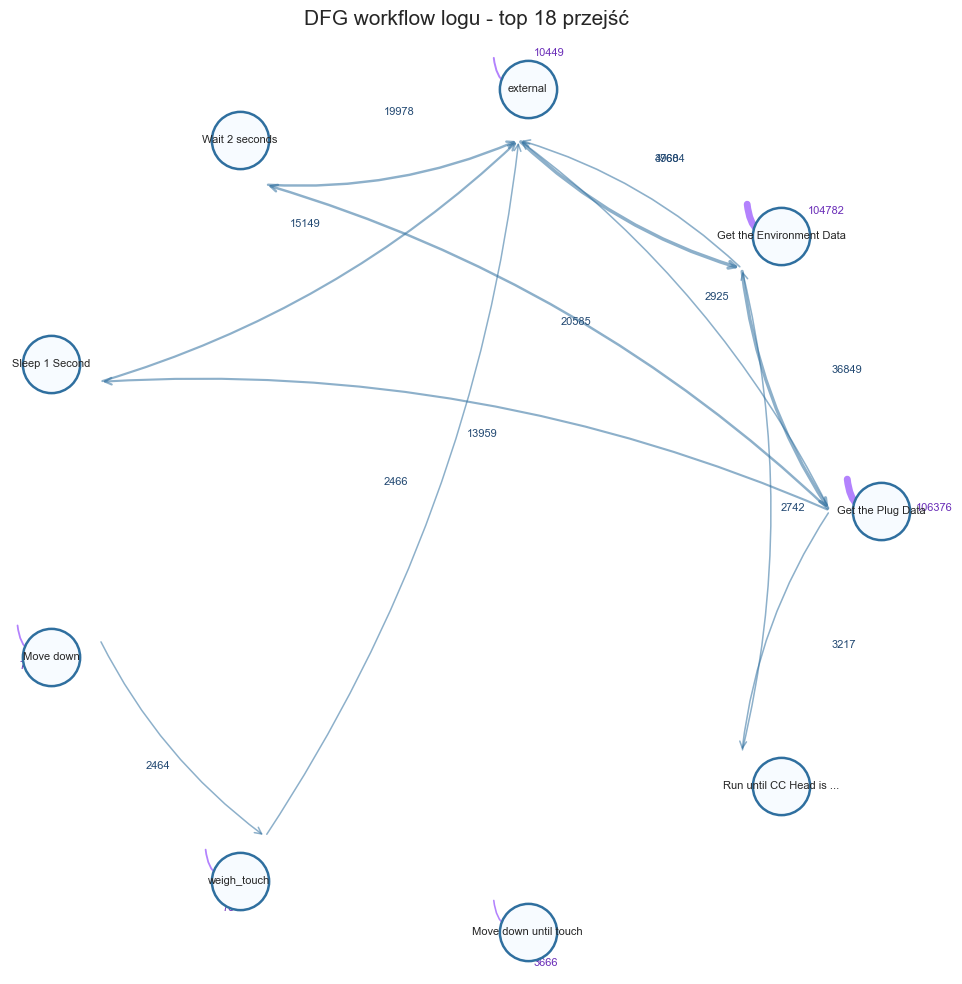

Zapisano: reports/milestone3/figures/m3_workflow_dfg_top18.png



### Model 1: DFG z workflow logu
DFG pokazuje najczęstsze bezpośrednie przejścia między nazwanymi aktywnościami CPEE. Najgrubsze krawędzie odpowiadają pętlom monitorowania, zwłaszcza powtarzalnemu pobieraniu danych środowiskowych i danych z wtyczki zasilającej. Ten model jest najbardziej wierny logowi, ale zawiera dużo technicznych zdarzeń pomiarowych.


In [110]:
# Wizualizacja DFG dla najczęstszych przejść bez zależności od Graphviz.
def draw_dfg(edge_df, output_path, top_n=18):
    top = edge_df.head(top_n).copy()
    nodes = pd.Index(pd.concat([top["activity_clean"], top["next_activity"]]).unique())
    n = len(nodes)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    pos = {node: (np.cos(a), np.sin(a)) for node, a in zip(nodes, angles)}

    fig, ax = plt.subplots(figsize=(13, 10))
    ax.set_aspect("equal")
    ax.axis("off")

    max_count = top["count"].max()
    for _, row in top.iterrows():
        a, b, cnt = row["activity_clean"], row["next_activity"], row["count"]
        x1, y1 = pos[a]
        x2, y2 = pos[b]
        if a == b:
            ax.annotate("", xy=(x1+0.02, y1+0.02), xytext=(x1-0.08, y1+0.08),
                        arrowprops=dict(arrowstyle="->", lw=1 + 4*cnt/max_count, color="#8a3ffc", alpha=0.65,
                                        connectionstyle="arc3,rad=0.7"))
            ax.text(x1*1.08, y1*1.08, str(cnt), fontsize=8, color="#6b2fb8")
        else:
            ax.annotate("", xy=(x2*0.88, y2*0.88), xytext=(x1*0.88, y1*0.88),
                        arrowprops=dict(arrowstyle="->", lw=1 + 4*cnt/max_count, color="#2f6f9f", alpha=0.55,
                                        connectionstyle="arc3,rad=0.12"))
            mx, my = (x1+x2)/2, (y1+y2)/2
            ax.text(mx, my, str(cnt), fontsize=8, color="#244a73")

    for node, (x, y) in pos.items():
        ax.scatter([x], [y], s=1700, color="#f7fbff", edgecolor="#2f6f9f", linewidth=1.8, zorder=3)
        label = str(node)
        if len(label) > 24:
            label = label[:21] + "..."
        ax.text(x, y, label, ha="center", va="center", fontsize=8, zorder=4, wrap=True)

    ax.set_title(f"DFG workflow logu - top {top_n} przejść", fontsize=15, pad=16)
    plt.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()

dfg_path = FIG_DIR / "m3_workflow_dfg_top18.png"
draw_dfg(transition_counts, dfg_path, top_n=18)
print("Zapisano:", dfg_path)
display(Markdown("""
### Model 1: DFG z workflow logu
DFG pokazuje najczęstsze bezpośrednie przejścia między nazwanymi aktywnościami CPEE. Najgrubsze krawędzie odpowiadają pętlom monitorowania, zwłaszcza powtarzalnemu pobieraniu danych środowiskowych i danych z wtyczki zasilającej. Ten model jest najbardziej wierny logowi, ale zawiera dużo technicznych zdarzeń pomiarowych.
"""))


## 4. Modele odkryte z workflow logu: minimum dwa algorytmy

W tej sekcji używamy PM4Py, jeśli jest dostępne. Notebook przygotowuje modele:

- **Inductive Miner** - stabilny model strukturalny, zwykle dobry jako model główny/BPMN,
- **Heuristics Miner** - model odporniejszy na szum i częste pętle,
- opcjonalnie **Alpha Miner** - prostszy model porównawczy, bardziej wrażliwy na szum.

Jeśli PM4Py nie jest zainstalowane, uruchom:

`pip install pm4py`

In [111]:
pm4py_log = df[["case_id", "activity_clean", "timestamp", "resource"]].rename(columns={
    "case_id": "case:concept:name",
    "activity_clean": "concept:name",
    "timestamp": "time:timestamp",
    "resource": "org:resource",
}).copy()

# Przyspieszenie pracy z bardzo dużym logiem: model można odkrywać na najczęstszych wariantach.
def add_variant_column(events):
    variants = (
        events.groupby("case:concept:name")["concept:name"]
        .agg(lambda s: " -> ".join(s.astype(str)))
        .rename("variant")
        .reset_index()
    )
    variant_freq = (
        variants["variant"]
        .value_counts()
        .rename_axis("variant")
        .reset_index(name="variant_count")
    )
    case_variant = variants.merge(variant_freq, on="variant", how="left")
    return events.merge(case_variant, on="case:concept:name", how="left")

pm4py_log = add_variant_column(pm4py_log)
coverage_target = 0.80
case_variants = pm4py_log[["case:concept:name", "variant", "variant_count"]].drop_duplicates()
variant_counts = (
    case_variants.groupby("variant", sort=False)["case:concept:name"]
    .nunique()
    .sort_values(ascending=False)
)
coverage = variant_counts.cumsum() / variant_counts.sum()
selected_variants = coverage[coverage <= coverage_target].index.tolist()
# Dodaj pierwszy wariant przekraczający próg, żeby realnie osiągnąć co najmniej 80% pokrycia.
first_over = coverage[coverage > coverage_target].head(1).index.tolist()
for variant in first_over:
    if variant not in selected_variants:
        selected_variants.append(variant)
if len(selected_variants) == 0:
    selected_variants = variant_counts.head(1).index.tolist()
model_log_df = pm4py_log[pm4py_log["variant"].isin(selected_variants)].drop(columns=["variant", "variant_count"]).copy()

print(f"Pełny log PM4Py: {pm4py_log['case:concept:name'].nunique():,} cases, {len(pm4py_log):,} zdarzeń")
print(f"Log do odkrywania modeli: {model_log_df['case:concept:name'].nunique():,} cases, {len(model_log_df):,} zdarzeń")
print(f"Pokrycie wariantami: ok. {coverage_target:.0%}; liczba wariantów użyta do modelu: {len(selected_variants)}")

display(variant_counts.head(15).reset_index().rename(columns={"index": "variant", "variant": "cases"}))

Pełny log PM4Py: 1,244 cases, 463,502 zdarzeń
Log do odkrywania modeli: 996 cases, 42,654 zdarzeń
Pokrycie wariantami: ok. 80%; liczba wariantów użyta do modelu: 22


,cases,case:concept:name
0,external -> external -> external -> external -...,165
1,external -> external -> external -> external -...,141
2,external -> external -> external -> external -...,92
3,external -> external -> external -> external -...,91
4,external -> external -> external -> external -...,70
5,external -> external -> external -> external -...,63
6,external -> external -> external -> external -...,56
7,external -> external -> external -> external -...,52
8,external -> external -> external -> external -...,49
9,external -> external -> external -> external -...,41


Zapisano model Inductive Miner BPMN: reports/milestone3/m3_workflow_inductive_miner.bpmn
Zapisano PNG Inductive Miner: reports/milestone3/figures/m3_workflow_inductive_miner.png


### Model 2: Inductive Miner - BPMN workflow logu

Inductive Miner buduje blokowy model procesu, który dobrze nadaje się jako główny model BPMN. W porównaniu z surowym DFG redukuje część szumu i porządkuje pętle oraz alternatywy w bardziej czytelną strukturę procesu.

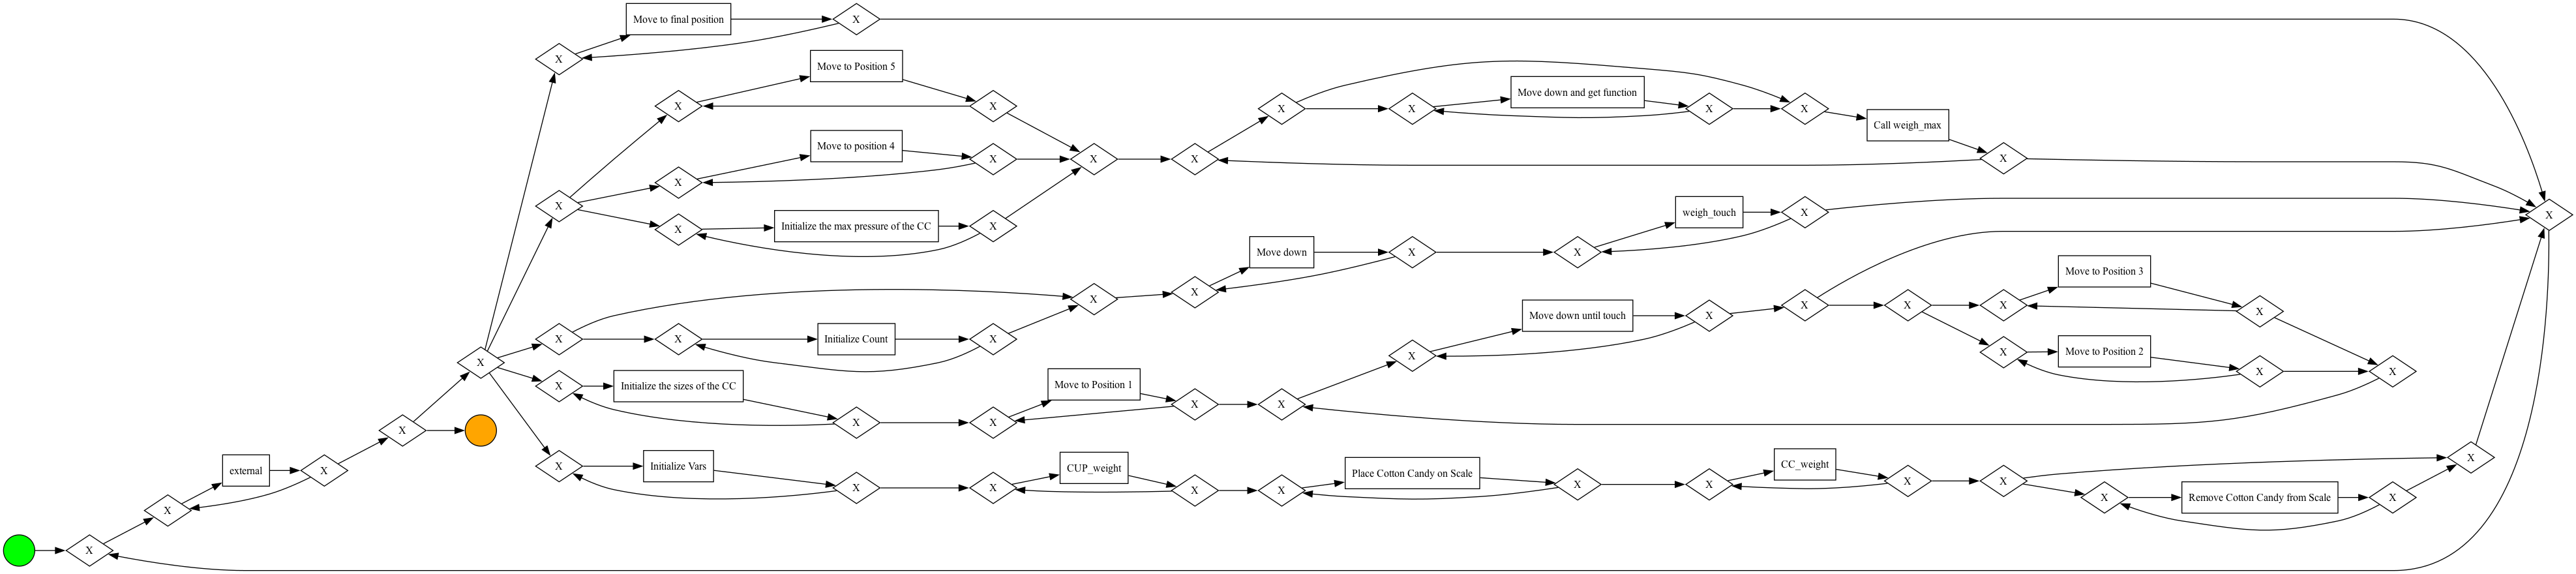

Plik: reports/milestone3/figures/m3_workflow_inductive_miner.png
Odkryto model Heuristics Miner.
Zapisano wizualizację Heuristics Miner: reports/milestone3/figures/m3_workflow_heuristics_miner.png


### Model 3: Heuristics Miner - workflow logu

Heuristics Miner jest przydatny dla logów zaszumionych i z częstymi pętlami. Model podkreśla zależności o wysokiej częstości, więc dobrze pokazuje dominujące zachowanie procesu, zwłaszcza cykliczne pobieranie pomiarów i przejścia do etapów oczekiwania, chłodzenia oraz ruchów robota.

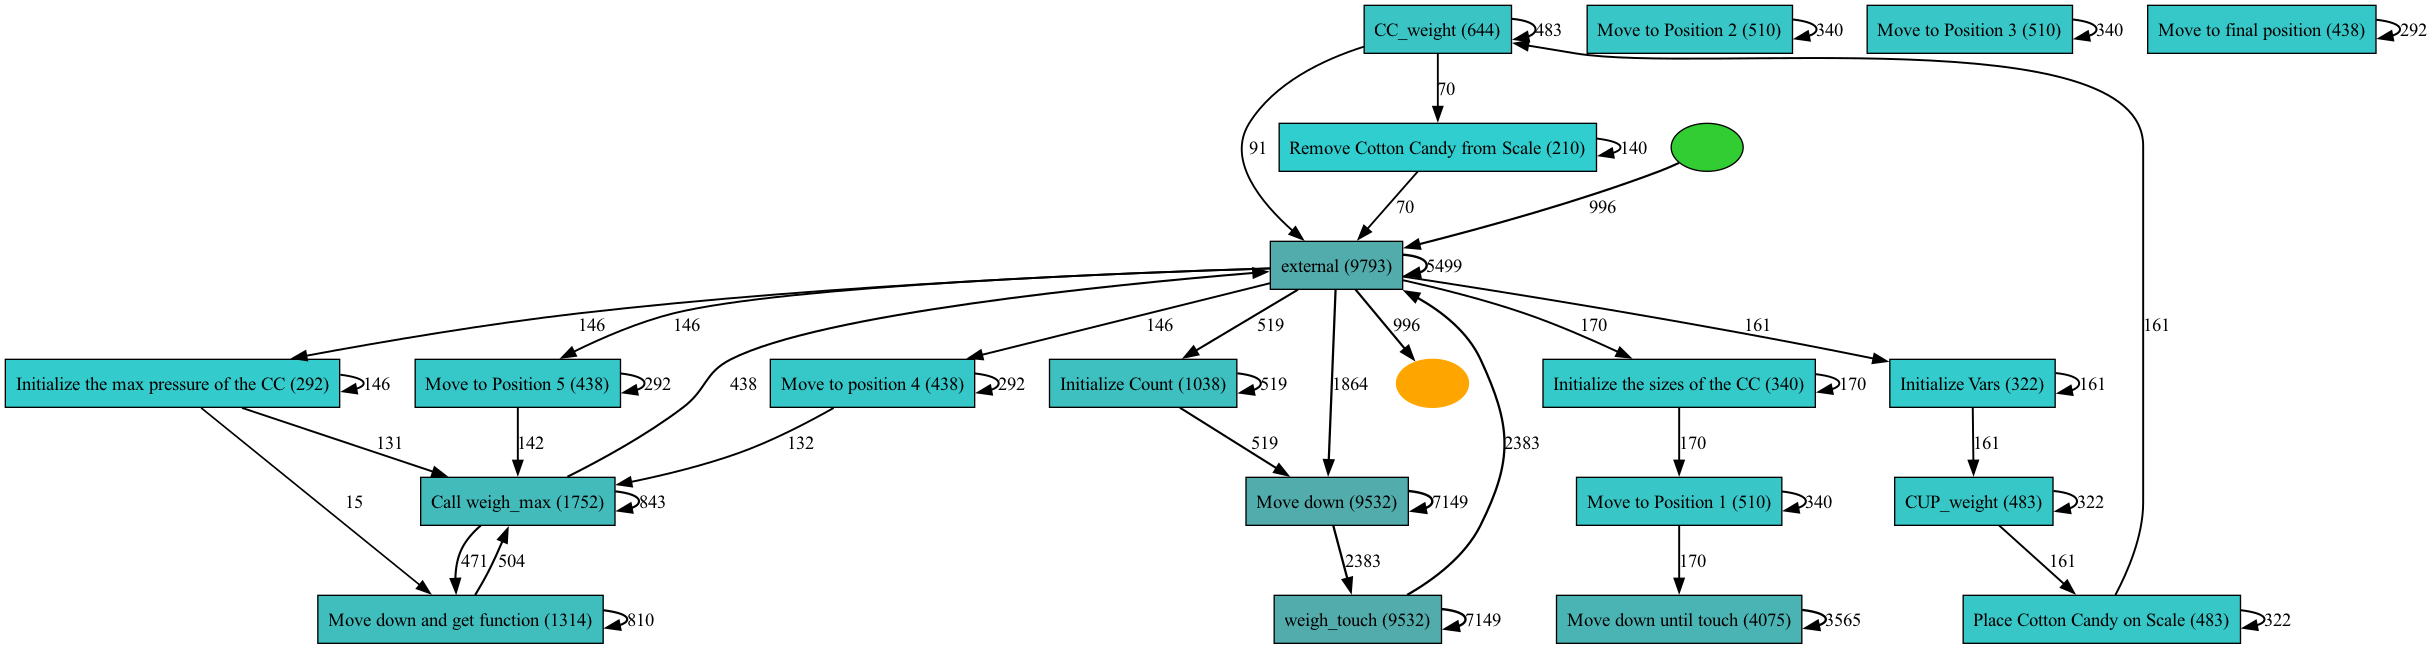

Plik: reports/milestone3/figures/m3_workflow_heuristics_miner.png
Zapisano Alpha Miner PNML: reports/milestone3/m3_workflow_alpha_miner.pnml
Zapisano PNG Alpha Miner: reports/milestone3/figures/m3_workflow_alpha_miner.png


### Model 4: Alpha Miner - sieć Petriego workflow logu

Alpha Miner traktujemy jako model porównawczy. Jest prostszy i bardziej wrażliwy na szum, dlatego przy naszym logu może być mniej czytelny niż Inductive lub Heuristics Miner, ale dobrze pokazuje podstawową strukturę przyczynową procesu.

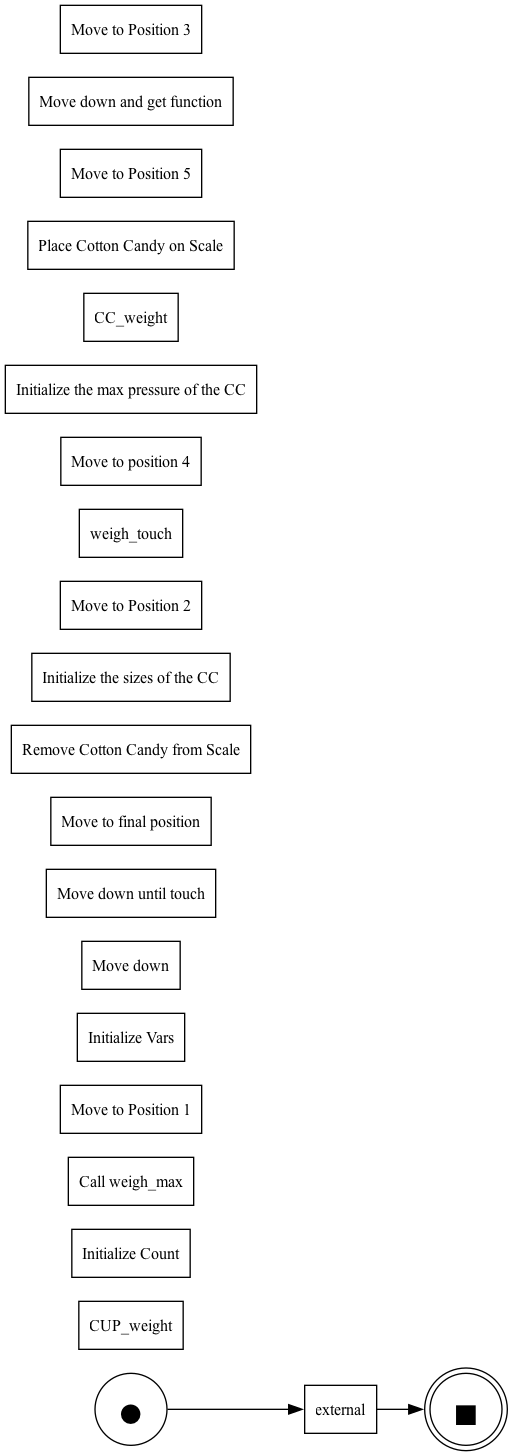

Plik: reports/milestone3/figures/m3_workflow_alpha_miner.png


In [112]:
if HAS_PM4PY:
    event_log = pm4py.format_dataframe(
        model_log_df,
        case_id="case:concept:name",
        activity_key="concept:name",
        timestamp_key="time:timestamp",
    )

    # 1) Inductive Miner
    try:
        inductive_tree = pm4py.discover_process_tree_inductive(event_log)
        inductive_bpmn = pm4py.convert_to_bpmn(inductive_tree)
        pm4py.write_bpmn(inductive_bpmn, str(REPORT_DIR / "m3_workflow_inductive_miner.bpmn"))
        print("Zapisano model Inductive Miner BPMN:", REPORT_DIR / "m3_workflow_inductive_miner.bpmn")
        if shutil.which("dot"):
            try:
                pm4py.save_vis_bpmn(inductive_bpmn, str(FIG_DIR / "m3_workflow_inductive_miner.png"))
                print("Zapisano PNG Inductive Miner:", FIG_DIR / "m3_workflow_inductive_miner.png")
                show_model_image(
                    FIG_DIR / "m3_workflow_inductive_miner.png",
                    "Model 2: Inductive Miner - BPMN workflow logu",
                    "Inductive Miner buduje blokowy model procesu, który dobrze nadaje się jako główny model BPMN. "
                    "W porównaniu z surowym DFG redukuje część szumu i porządkuje pętle oraz alternatywy w bardziej czytelną strukturę procesu."
                )
            except Exception as vis_error:
                print("Nie udało się zapisać PNG BPMN z Inductive Miner:", vis_error)
        else:
            print("Pominięto PNG Inductive Miner: brak Graphviz dot w PATH.")
    except Exception as e:
        print("Inductive Miner - błąd tworzenia/zapisu modelu:", e)

    # 2) Heuristics Miner
    try:
        heu_net = pm4py.discover_heuristics_net(event_log)
        print("Odkryto model Heuristics Miner.")
        if shutil.which("dot"):
            try:
                pm4py.save_vis_heuristics_net(heu_net, str(FIG_DIR / "m3_workflow_heuristics_miner.png"))
                print("Zapisano wizualizację Heuristics Miner:", FIG_DIR / "m3_workflow_heuristics_miner.png")
                show_model_image(
                    FIG_DIR / "m3_workflow_heuristics_miner.png",
                    "Model 3: Heuristics Miner - workflow logu",
                    "Heuristics Miner jest przydatny dla logów zaszumionych i z częstymi pętlami. "
                    "Model podkreśla zależności o wysokiej częstości, więc dobrze pokazuje dominujące zachowanie procesu, "
                    "zwłaszcza cykliczne pobieranie pomiarów i przejścia do etapów oczekiwania, chłodzenia oraz ruchów robota."
                )
            except Exception as vis_error:
                print("Nie udało się zapisać PNG Heuristics Miner:", vis_error)
        else:
            print("Pominięto PNG Heuristics Miner: brak Graphviz dot w PATH.")
    except Exception as e:
        print("Heuristics Miner - błąd tworzenia modelu:", e)

    # 3) Alpha Miner jako dodatkowy model porównawczy
    try:
        net, im, fm = pm4py.discover_petri_net_alpha(event_log)
        pm4py.write_pnml(net, im, fm, str(REPORT_DIR / "m3_workflow_alpha_miner.pnml"))
        print("Zapisano Alpha Miner PNML:", REPORT_DIR / "m3_workflow_alpha_miner.pnml")
        if shutil.which("dot"):
            try:
                pm4py.save_vis_petri_net(net, im, fm, str(FIG_DIR / "m3_workflow_alpha_miner.png"))
                print("Zapisano PNG Alpha Miner:", FIG_DIR / "m3_workflow_alpha_miner.png")
                show_model_image(
                    FIG_DIR / "m3_workflow_alpha_miner.png",
                    "Model 4: Alpha Miner - sieć Petriego workflow logu",
                    "Alpha Miner traktujemy jako model porównawczy. Jest prostszy i bardziej wrażliwy na szum, "
                    "dlatego przy naszym logu może być mniej czytelny niż Inductive lub Heuristics Miner, ale dobrze pokazuje podstawową strukturę przyczynową procesu."
                )
            except Exception as vis_error:
                print("Nie udało się zapisać PNG Alpha Miner:", vis_error)
        else:
            print("Pominięto PNG Alpha Miner: brak Graphviz dot w PATH.")
    except Exception as e:
        print("Alpha Miner - błąd tworzenia/zapisu modelu:", e)
else:
    print("PM4Py nie jest dostępne - ta sekcja wygeneruje modele po instalacji biblioteki pm4py.")


## 5. Analiza zasobów i wąskich gardeł workflow logu

W danych nie ma klasycznego pracownika/wykonawcy, dlatego jako przybliżenie zasobu stosujemy host z endpointu, zgodnie z Milestone 2. Wąskie gardła identyfikujemy przez medianę i średni czas przejścia między aktywnościami.

In [113]:
# Obciążenie zasobów endpoint/resource
resource_load = (
    df.dropna(subset=["resource"])
    .groupby("resource")
    .agg(events=("activity_clean", "count"), activities=("activity_clean", "nunique"), cases=("case_id", "nunique"))
    .sort_values("events", ascending=False)
)
print("Obciążenie zasobów proxy (endpoint host):")
display(resource_load.head(20))
resource_load.to_csv(REPORT_DIR / "m3_resource_load.csv")

# Najwolniejsze częste przejścia
bottlenecks = transition_times[transition_times["count"] >= 20].copy()
bottlenecks = bottlenecks.sort_values("median", ascending=False).head(20)
print("Potencjalne wąskie gardła - częste przejścia o największej medianie czasu:")
display(bottlenecks)
bottlenecks.to_csv(REPORT_DIR / "m3_workflow_bottlenecks.csv", index=False)

Obciążenie zasobów proxy (endpoint host):


,events,activities,cases
resource,,,
lab.bpm.in.tum.de,335541,31,1222
cpee.org,12808,12,383


Potencjalne wąskie gardła - częste przejścia o największej medianie czasu:


,activity_clean,next_activity,count,median,mean,max
15,Call The Cottonbot with Data Collection,external,32,23.853241,234.509499,3086.798502
127,Get the Plug Data,Wait 2 seconds,20585,2.025792,2.123655,6.853690
216,Run until CC Head is optimally cooled,Wait 2 seconds,125,2.017749,2.019233,2.044312
266,Set waiting time,Wait 2 seconds,28,2.006612,2.006171,5.999280
164,Measure the pressure of the three sides of the...,Wait 2 seconds,49,2.004401,1.622376,3.998493
432,external,Wait 2 seconds,69,2.004210,1.586431,2.050725
208,Place the Wood Stick in Center,Wait 2 seconds,33,1.973420,1.628069,5.939832
178,Move down and get function,Call weigh_max,628,1.303404,1.451622,6.427041
186,Move to Position 1,Move to Position 1,352,1.218289,4.405147,12.991302
210,Remove Cotton Candy from Scale,Remove Cotton Candy from Scale,140,1.216423,6.625133,14.905937


## 6. Dane IoT: event log z klasteryzacji sensorów

Zgodnie z wymaganiem prowadzącego nie używamy nazw zdarzeń jako ground truth do klasteryzacji. Bierzemy wyłącznie odczyty sensorów z `*-process.yaml`, agregujemy je do okien czasowych i klasteryzujemy profile pomiarów.

Parametry przeniesione z Milestone 2:
- okno czasowe: **5 min**,
- sensory: najczęstsze sensory liczbowe,
- model: UMAP + DBSCAN jako główny wariant interpretowalny,
- K-Means jako model porównawczy.

In [114]:
def find_stream_points(node, context=None):
    """Rekurencyjnie wyciąga punkty sensorowe ze struktur stream:datastream."""
    if context is None:
        context = {}
    points = []
    if isinstance(node, dict):
        new_context = dict(context)
        for key in ["stream:name", "stream:source"]:
            if key in node:
                new_context[key] = node[key]
        if "stream:point" in node:
            sp = node["stream:point"]
            if isinstance(sp, list):
                for item in sp:
                    points.extend(find_stream_points(item, new_context))
            elif isinstance(sp, dict):
                row = dict(new_context)
                row.update(sp)
                points.append(row)
        for value in node.values():
            if isinstance(value, (dict, list)):
                points.extend(find_stream_points(value, new_context))
    elif isinstance(node, list):
        for item in node:
            points.extend(find_stream_points(item, context))
    return points

def extract_sensor_rows_from_process_file(path):
    if not HAS_YAML:
        raise ImportError("PyYAML jest wymagany do wczytania *-process.yaml")
    rows = []
    with path.open("r", encoding="utf-8") as f:
        docs = yaml.safe_load_all(f)
        for doc_idx, doc in enumerate(docs):
            if not isinstance(doc, dict) or "event" not in doc:
                continue
            event = doc.get("event") or {}
            case_id = event.get("cpee:instance") or event.get("concept:instance") or str(path.relative_to(DATA_DIR))
            event_ts = event.get("time:timestamp")
            datastream = event.get("stream:datastream")
            if datastream is None:
                continue
            for p in find_stream_points(datastream):
                rows.append({
                    "file": str(path.relative_to(DATA_DIR)).replace("\\", "/"),
                    "batch": path.parent.name,
                    "case_id": case_id,
                    "event_timestamp_raw": event_ts,
                    "stream_name": p.get("stream:name"),
                    "stream_source": p.get("stream:source"),
                    "sensor_id": p.get("stream:id") or p.get("id") or p.get("name"),
                    "sensor_timestamp_raw": p.get("stream:timestamp") or p.get("timestamp"),
                    "sensor_value_raw": p.get("stream:value") or p.get("value"),
                })
    return rows

sensor_rows = []
for i, path in enumerate(process_files, start=1):
    sensor_rows.extend(extract_sensor_rows_from_process_file(path))
    if i % 5 == 0:
        print(f"Przetworzono {i}/{len(process_files)} plików process.yaml, punktów: {len(sensor_rows):,}")

df_sensors = pd.DataFrame(sensor_rows)
print(f"Wczytano punktów sensorowych: {len(df_sensors):,}")
if not df_sensors.empty:
    df_sensors["sensor_timestamp"] = pd.to_datetime(df_sensors["sensor_timestamp_raw"], errors="coerce", utc=True)
    df_sensors["event_timestamp"] = pd.to_datetime(df_sensors["event_timestamp_raw"], errors="coerce", utc=True)
    df_sensors["timestamp"] = df_sensors["sensor_timestamp"].fillna(df_sensors["event_timestamp"])
    df_sensors["sensor_value"] = pd.to_numeric(df_sensors["sensor_value_raw"], errors="coerce")
    print("Top sensory:")
    display(df_sensors["sensor_id"].value_counts().head(15))
    display(df_sensors.head())

Przetworzono 5/33 plików process.yaml, punktów: 6,695
Przetworzono 10/33 plików process.yaml, punktów: 13,972
Przetworzono 15/33 plików process.yaml, punktów: 21,806
Przetworzono 20/33 plików process.yaml, punktów: 26,260
Przetworzono 25/33 plików process.yaml, punktów: 31,171
Przetworzono 30/33 plików process.yaml, punktów: 35,752
Wczytano punktów sensorowych: 38,207
Top sensory:


sensor_id
humidity       9434
temperature    9434
head           4717
ambient        4717
current        4700
power          4700
pos1            135
pos2             82
pos3             82
pressures        78
weight           68
Name: count, dtype: int64

,file,batch,case_id,event_timestamp_raw,stream_name,stream_source,sensor_id,sensor_timestamp_raw,sensor_value_raw,sensor_timestamp,event_timestamp,timestamp,sensor_value
0,batch-0/0-0-process.yaml,batch-0,ac539644-d15f-47cb-be72-619ec2fb73eb,NaN,None,sensors,humidity,2025-07-28 01:44:38.45,63.73,2025-07-28 01:44:38.450000+00:00,NaT,2025-07-28 01:44:38.450000+00:00,63.73
1,batch-0/0-0-process.yaml,batch-0,ac539644-d15f-47cb-be72-619ec2fb73eb,NaN,None,sensors,temperature,2025-07-28 01:44:38.45,24.59,2025-07-28 01:44:38.450000+00:00,NaT,2025-07-28 01:44:38.450000+00:00,24.59
2,batch-0/0-0-process.yaml,batch-0,ac539644-d15f-47cb-be72-619ec2fb73eb,NaN,None,sensors,humidity,2025-07-28 01:44:38.45,39.26,2025-07-28 01:44:38.450000+00:00,NaT,2025-07-28 01:44:38.450000+00:00,39.26
3,batch-0/0-0-process.yaml,batch-0,ac539644-d15f-47cb-be72-619ec2fb73eb,NaN,None,sensors,temperature,2025-07-28 01:44:38.45,37.90,2025-07-28 01:44:38.450000+00:00,NaT,2025-07-28 01:44:38.450000+00:00,37.90
4,batch-0/0-0-process.yaml,batch-0,ac539644-d15f-47cb-be72-619ec2fb73eb,NaN,None,sensors,head,2025-07-28 01:44:38.45,25.67,2025-07-28 01:44:38.450000+00:00,NaT,2025-07-28 01:44:38.450000+00:00,25.67


In [115]:
WINDOW_SIZE = "5min"
MIN_SENSORS_PER_WINDOW = 2
TOP_N_SENSORS = 10

if not HAS_SKLEARN:
    raise ImportError("Ta sekcja wymaga scikit-learn")
if df_sensors.empty:
    raise ValueError("Brak danych sensorowych")

sensor_window_df = df_sensors.dropna(subset=["sensor_id", "timestamp", "sensor_value"]).copy()
top_sensors_window = sensor_window_df["sensor_id"].value_counts().head(TOP_N_SENSORS).index.tolist()
sensor_window_df = sensor_window_df[sensor_window_df["sensor_id"].isin(top_sensors_window)].copy()
sensor_window_df["time_window"] = sensor_window_df["timestamp"].dt.floor(WINDOW_SIZE)

window_matrix_raw = sensor_window_df.pivot_table(
    index="time_window",
    columns="sensor_id",
    values="sensor_value",
    aggfunc="mean",
).sort_index()
window_counts = sensor_window_df.pivot_table(
    index="time_window",
    columns="sensor_id",
    values="sensor_value",
    aggfunc="count",
).reindex(window_matrix_raw.index)

sensors_present = window_matrix_raw.notna().sum(axis=1)
readings_per_window = window_counts.fillna(0).sum(axis=1)
window_matrix = window_matrix_raw[sensors_present >= MIN_SENSORS_PER_WINDOW].copy()

X_window = window_matrix.interpolate(method="time", limit_direction="both")
X_window = X_window.fillna(X_window.median())
X_window = X_window.loc[:, X_window.std() > 0]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_window)
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=min(30, max(5, len(X_window)//20), len(X_window)-1), min_dist=0.05, random_state=42)
    X_embedding = reducer.fit_transform(X_scaled)
    embedding_name = "UMAP"
else:
    reducer = PCA(n_components=2, random_state=42)
    X_embedding = reducer.fit_transform(X_scaled)
    embedding_name = "PCA fallback"

# K-Means: wybór k wg silhouette
k_candidates = range(2, min(15, len(X_window)-1))
k_scores = []
for k in k_candidates:
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    k_scores.append((k, score))
best_k, best_score = max(k_scores, key=lambda x: x[1])
kmeans_labels = KMeans(n_clusters=best_k, random_state=42, n_init=20).fit_predict(X_scaled)

# DBSCAN: parametry z Milestone 2; dla PCA fallback nadal działają jako punkt startowy.
dbscan = DBSCAN(eps=0.32, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_embedding)

n_db_clusters = len(set(dbscan_labels)) - (1 if -1 in set(dbscan_labels) else 0)
n_db_noise = int((dbscan_labels == -1).sum())

df_sensor_windows = pd.DataFrame({
    "time_window": X_window.index,
    "kmeans_cluster": kmeans_labels,
    "dbscan_cluster": dbscan_labels,
    "embed_x": X_embedding[:, 0],
    "embed_y": X_embedding[:, 1],
    "n_sensors_present": sensors_present.reindex(X_window.index).values,
    "n_readings": readings_per_window.reindex(X_window.index).values,
}).set_index("time_window")

print(f"Okno czasowe: {WINDOW_SIZE}")
print(f"Sensory użyte w klasteryzacji: {top_sensors_window}")
print(f"Macierz okien: {X_window.shape[0]} okien x {X_window.shape[1]} sensorów")
print(f"K-Means: k={best_k}, silhouette={best_score:.3f}")
print(f"DBSCAN ({embedding_name}): klastry={n_db_clusters}, szum={n_db_noise}, eps=0.213, min_samples=3")

display(df_sensor_windows.head())
df_sensor_windows.reset_index().to_csv(REPORT_DIR / "m3_iot_clustered_windows.csv", index=False)

Okno czasowe: 5min
Sensory użyte w klasteryzacji: ['humidity', 'temperature', 'head', 'ambient', 'current', 'power', 'weight', 'pos1', 'pos3', 'pos2']
Macierz okien: 87 okien x 10 sensorów
K-Means: k=14, silhouette=0.471
DBSCAN (UMAP): klastry=14, szum=13, eps=0.213, min_samples=3


,kmeans_cluster,dbscan_cluster,embed_x,embed_y,n_sensors_present,n_readings
time_window,,,,,,
2025-07-27 23:50:00+00:00,7,0,17.569584,5.887033,3,3.0
2025-07-27 23:55:00+00:00,7,0,17.742048,5.691583,3,3.0
2025-07-28 00:05:00+00:00,7,0,17.590448,5.808616,3,3.0
2025-07-28 00:15:00+00:00,7,0,17.669687,5.663969,3,3.0
2025-07-28 01:40:00+00:00,7,-1,18.197006,5.529231,4,60.0


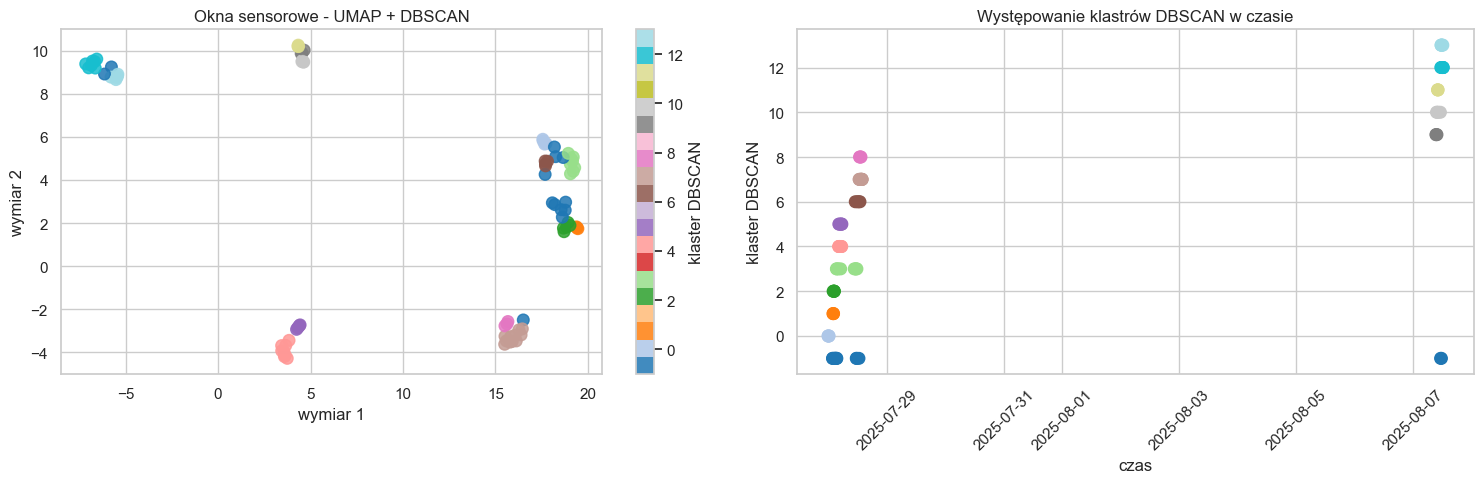

Rozmiary klastrów DBSCAN:


dbscan_cluster
-1     13
 0      4
 1      3
 2      5
 3      8
 4      9
 5      5
 6      4
 7     11
 8      3
 9      3
 10     4
 11     3
 12     7
 13     5
Name: n_windows, dtype: int64

In [116]:
# Występowanie klastrów w czasie
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

scatter = axes[0].scatter(df_sensor_windows["embed_x"], df_sensor_windows["embed_y"], c=df_sensor_windows["dbscan_cluster"], cmap="tab20", s=70, alpha=0.85)
axes[0].set_title(f"Okna sensorowe - {embedding_name} + DBSCAN")
axes[0].set_xlabel("wymiar 1")
axes[0].set_ylabel("wymiar 2")
plt.colorbar(scatter, ax=axes[0], label="klaster DBSCAN")

plot_df = df_sensor_windows.reset_index().sort_values("time_window")
axes[1].scatter(plot_df["time_window"], plot_df["dbscan_cluster"], c=plot_df["dbscan_cluster"], cmap="tab20", s=70)
axes[1].set_title("Występowanie klastrów DBSCAN w czasie")
axes[1].set_xlabel("czas")
axes[1].set_ylabel("klaster DBSCAN")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "m3_iot_clusters_over_time.png", dpi=180, bbox_inches="tight")
plt.show()

cluster_sizes = df_sensor_windows["dbscan_cluster"].value_counts().sort_index()
print("Rozmiary klastrów DBSCAN:")
display(cluster_sizes.rename("n_windows"))

Profile klastrów DBSCAN - średnie wartości sensorów:


,ambient,current,head,humidity,pos1,pos2,pos3,power,temperature,weight,n_windows
dbscan_cluster,,,,,,,,,,,
-1,28.07,3.87,57.42,53.98,12.98,4.25,10.79,840.43,29.03,0.28,13
0,25.96,4.04,25.43,62.56,3.00,2.75,3.75,876.48,25.62,1.02,4
1,31.79,2.52,72.38,48.65,16.61,2.91,7.15,552.84,33.01,1.02,3
2,31.97,3.53,78.01,47.79,15.20,3.16,7.59,761.52,33.68,1.02,5
3,26.84,4.18,43.76,57.58,16.84,11.86,13.73,913.21,26.89,1.01,8
4,31.87,2.40,66.61,47.08,15.08,10.07,17.39,523.37,32.50,1.02,9
5,32.36,3.48,74.04,46.79,15.41,10.07,17.10,752.24,32.91,1.02,5
6,25.96,4.30,33.06,60.36,6.30,4.49,25.66,939.18,25.41,0.65,4
7,30.66,2.92,69.76,49.08,4.64,5.37,23.48,634.38,31.71,0.86,11


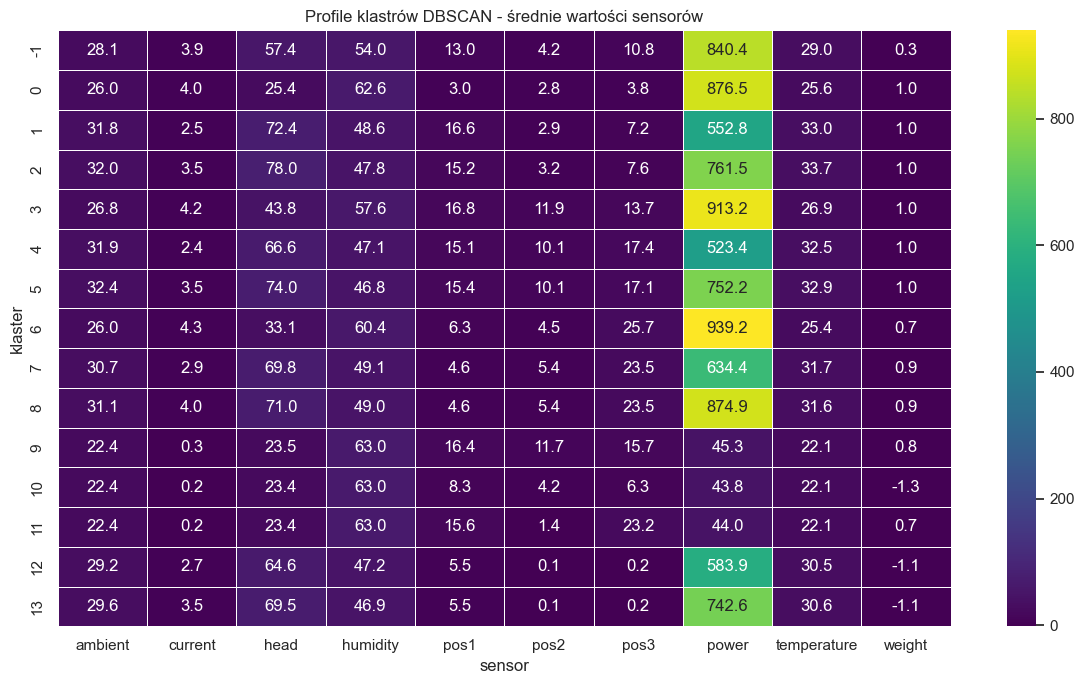

In [117]:
# Cechy charakterystyczne klastrów
cluster_profiles = X_window.copy()
cluster_profiles["dbscan_cluster"] = df_sensor_windows["dbscan_cluster"]
profile_means = cluster_profiles.groupby("dbscan_cluster").mean().round(2)
profile_counts = df_sensor_windows["dbscan_cluster"].value_counts().sort_index().rename("n_windows")
profile_table = profile_means.merge(profile_counts, left_index=True, right_index=True).sort_index()

print("Profile klastrów DBSCAN - średnie wartości sensorów:")
display(profile_table)
profile_table.to_csv(REPORT_DIR / "m3_iot_dbscan_cluster_profiles.csv")

plt.figure(figsize=(12, 7))
sns.heatmap(profile_means, cmap="viridis", annot=True, fmt=".1f", linewidths=0.5)
plt.title("Profile klastrów DBSCAN - średnie wartości sensorów")
plt.xlabel("sensor")
plt.ylabel("klaster")
plt.tight_layout()
plt.savefig(FIG_DIR / "m3_iot_cluster_profiles_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

In [118]:
# Interpretowalne nazwy klastrów na podstawie profili sensorowych.
def name_cluster(row, medians):
    if row.name == -1:
        return "Nietypowy profil / szum"
    power = row.get("power", np.nan)
    current = row.get("current", np.nan)
    head = row.get("head", np.nan)
    temp = row.get("temperature", np.nan)
    humidity = row.get("humidity", np.nan)

    low_power = pd.notna(power) and power <= max(120, medians.get("power", 0) * 0.25)
    high_power = pd.notna(power) and power >= medians.get("power", 0) * 1.15
    high_head = pd.notna(head) and head >= medians.get("head", 0) * 1.08
    low_head = pd.notna(head) and head <= medians.get("head", 0) * 0.65
    high_humidity = pd.notna(humidity) and humidity >= medians.get("humidity", 0) * 1.12

    if low_power and low_head:
        return "Postój / stan chłodny"
    if high_power and high_head:
        return "Intensywna praca grzania"
    if high_power and not high_head:
        return "Rozruch / dogrzewanie"
    if high_head and not high_power:
        return "Chłodzenie po pracy"
    if high_humidity and low_power:
        return "Stan środowiskowy bez obciążenia"
    return "Normalna praca stabilna"

medians = X_window.median(numeric_only=True)
cluster_names = {idx: name_cluster(row, medians) for idx, row in profile_means.iterrows()}
cluster_name_df = pd.DataFrame({
    "dbscan_cluster": list(cluster_names.keys()),
    "cluster_name": list(cluster_names.values()),
}).sort_values("dbscan_cluster")

df_sensor_windows_named = df_sensor_windows.reset_index().merge(cluster_name_df, on="dbscan_cluster", how="left")
print("Nazwy klastrów:")
display(cluster_name_df)
cluster_name_df.to_csv(REPORT_DIR / "m3_iot_cluster_names.csv", index=False)

Nazwy klastrów:


,dbscan_cluster,cluster_name
0,-1,Nietypowy profil / szum
1,0,Rozruch / dogrzewanie
2,1,Chłodzenie po pracy
3,2,Chłodzenie po pracy
4,3,Rozruch / dogrzewanie
5,4,Normalna praca stabilna
6,5,Chłodzenie po pracy
7,6,Rozruch / dogrzewanie
8,7,Normalna praca stabilna
9,8,Intensywna praca grzania


## 7. Przejścia między klastrami IoT i model procesu z klastrów

Kolejne okna sensorowe traktujemy jako zdarzenia. Etykietą zdarzenia jest interpretowalna nazwa klastra. Na tej podstawie budujemy event log i DFG dla danych IoT.

In [119]:
iot_events = df_sensor_windows_named.sort_values("time_window").copy()
iot_events["case_id"] = "iot_timeline"
iot_events["activity"] = iot_events["cluster_name"]
iot_events["next_activity"] = iot_events["activity"].shift(-1)
iot_events["next_cluster"] = iot_events["dbscan_cluster"].shift(-1)

iot_transitions = (
    iot_events.dropna(subset=["next_activity"])
    .groupby(["activity", "next_activity"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

iot_cluster_transition_matrix = pd.crosstab(
    iot_events["dbscan_cluster"],
    iot_events["next_cluster"],
).fillna(0).astype(int)

print("Przejścia między nazwanymi klastrami IoT:")
display(iot_transitions)
print("Macierz przejść między numerami klastrów:")
display(iot_cluster_transition_matrix)

iot_transitions.to_csv(REPORT_DIR / "m3_iot_named_cluster_transitions.csv", index=False)
iot_cluster_transition_matrix.to_csv(REPORT_DIR / "m3_iot_cluster_transition_matrix.csv")

Przejścia między nazwanymi klastrami IoT:


,activity,next_activity,count
13,Normalna praca stabilna,Normalna praca stabilna,20
20,Rozruch / dogrzewanie,Rozruch / dogrzewanie,9
17,Postój / stan chłodny,Postój / stan chłodny,9
0,Chłodzenie po pracy,Chłodzenie po pracy,7
7,Nietypowy profil / szum,Nietypowy profil / szum,6
10,Normalna praca stabilna,Chłodzenie po pracy,5
2,Chłodzenie po pracy,Normalna praca stabilna,4
18,Rozruch / dogrzewanie,Nietypowy profil / szum,4
19,Rozruch / dogrzewanie,Normalna praca stabilna,3
8,Nietypowy profil / szum,Normalna praca stabilna,3


Macierz przejść między numerami klastrów:


next_cluster,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0
dbscan_cluster,,,,,,,,,,,,,,,
-1,6,0,1,0,3,0,0,0,1,0,0,0,0,1,1
0,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0
2,1,0,1,3,0,0,0,0,0,0,0,0,0,0,0
3,2,0,0,0,2,2,0,2,0,0,0,0,0,0,0
4,0,0,0,0,1,3,5,0,0,0,0,0,0,0,0
5,0,0,0,0,1,4,0,0,0,0,0,0,0,0,0
6,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,7,3,1,0,0,0,0


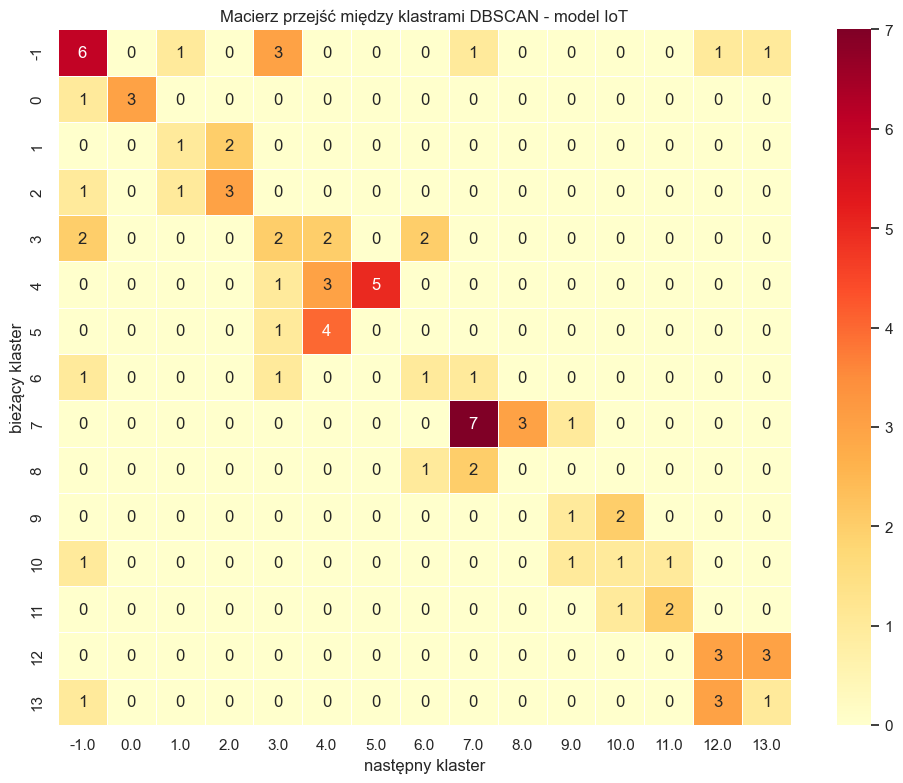

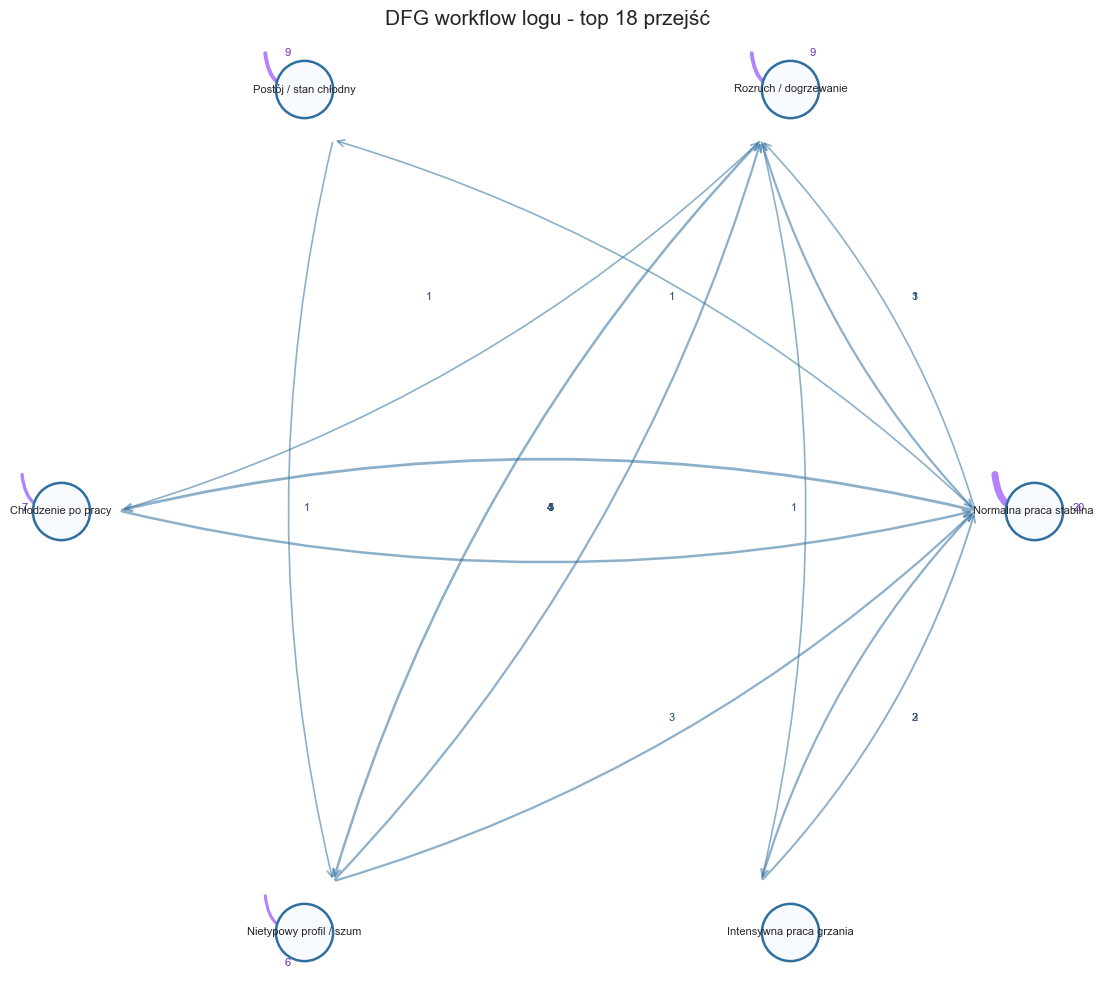

Zapisano: reports/milestone3/figures/m3_iot_dfg_named_clusters.png



### Model 5: DFG z nazwanych klastrów IoT
Ten model nie korzysta z nazw aktywności workflow. Aktywnościami są interpretowalne stany maszyny otrzymane z klasteryzacji sensorów. Krawędzie pokazują, jak profile pracy maszyny przechodzą między postojem, rozruchem, normalną pracą, intensywnym grzaniem, chłodzeniem i stanami nietypowymi.


In [120]:
plt.figure(figsize=(10, 8))
sns.heatmap(iot_cluster_transition_matrix, cmap="YlOrRd", annot=True, fmt="d", linewidths=0.5)
plt.title("Macierz przejść między klastrami DBSCAN - model IoT")
plt.xlabel("następny klaster")
plt.ylabel("bieżący klaster")
plt.tight_layout()
plt.savefig(FIG_DIR / "m3_iot_cluster_transition_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

dfg_iot_path = FIG_DIR / "m3_iot_dfg_named_clusters.png"
draw_dfg(iot_transitions.rename(columns={"activity": "activity_clean", "next_activity": "next_activity"}), dfg_iot_path, top_n=min(18, len(iot_transitions)))
print("Zapisano:", dfg_iot_path)
display(Markdown("""
### Model 5: DFG z nazwanych klastrów IoT
Ten model nie korzysta z nazw aktywności workflow. Aktywnościami są interpretowalne stany maszyny otrzymane z klasteryzacji sensorów. Krawędzie pokazują, jak profile pracy maszyny przechodzą między postojem, rozruchem, normalną pracą, intensywnym grzaniem, chłodzeniem i stanami nietypowymi.
"""))


Zapisano BPMN z klastrów IoT: reports/milestone3/m3_iot_cluster_inductive_miner.bpmn
Zapisano PNG BPMN z klastrów IoT: reports/milestone3/figures/m3_iot_cluster_inductive_miner.png


### Model 6: BPMN odkryty z klastrów IoT

To docelowy model procesu zbudowany z danych sensorowych: kolejne okna czasowe są zdarzeniami, a etykietą zdarzenia jest nazwa klastra. Model pokazuje proces jako sekwencję fizycznych stanów maszyny, a nie jako listę technicznych wywołań CPEE.

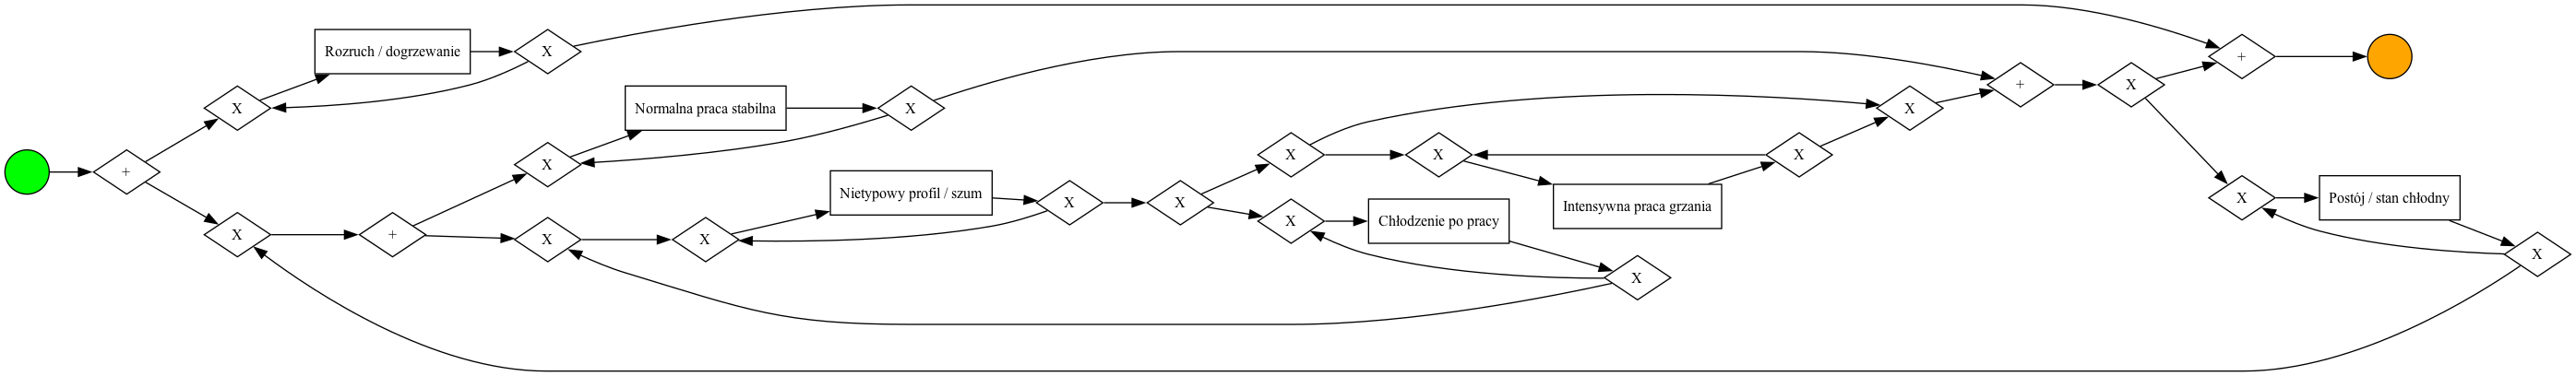

Plik: reports/milestone3/figures/m3_iot_cluster_inductive_miner.png


In [121]:
# Próba odkrycia modelu PM4Py również dla logu IoT z klastrów.
if HAS_PM4PY:
    iot_pm4py_df = iot_events[["case_id", "activity", "time_window"]].rename(columns={
        "case_id": "case:concept:name",
        "activity": "concept:name",
        "time_window": "time:timestamp",
    })
    iot_pm4py_df["time:timestamp"] = pd.to_datetime(iot_pm4py_df["time:timestamp"], utc=True)
    iot_log = pm4py.format_dataframe(
        iot_pm4py_df,
        case_id="case:concept:name",
        activity_key="concept:name",
        timestamp_key="time:timestamp",
    )
    try:
        iot_tree = pm4py.discover_process_tree_inductive(iot_log)
        iot_bpmn = pm4py.convert_to_bpmn(iot_tree)
        pm4py.write_bpmn(iot_bpmn, str(REPORT_DIR / "m3_iot_cluster_inductive_miner.bpmn"))
        print("Zapisano BPMN z klastrów IoT:", REPORT_DIR / "m3_iot_cluster_inductive_miner.bpmn")
        if shutil.which("dot"):
            try:
                pm4py.save_vis_bpmn(iot_bpmn, str(FIG_DIR / "m3_iot_cluster_inductive_miner.png"))
                print("Zapisano PNG BPMN z klastrów IoT:", FIG_DIR / "m3_iot_cluster_inductive_miner.png")
                show_model_image(
                    FIG_DIR / "m3_iot_cluster_inductive_miner.png",
                    "Model 6: BPMN odkryty z klastrów IoT",
                    "To docelowy model procesu zbudowany z danych sensorowych: kolejne okna czasowe są zdarzeniami, a etykietą zdarzenia jest nazwa klastra. "
                    "Model pokazuje proces jako sekwencję fizycznych stanów maszyny, a nie jako listę technicznych wywołań CPEE."
                )
            except Exception as vis_error:
                print("Nie udało się zapisać PNG modelu IoT BPMN:", vis_error)
        else:
            print("Pominięto PNG BPMN z klastrów IoT: brak Graphviz dot w PATH.")
    except Exception as e:
        print("Nie udało się odkryć/zapisać BPMN dla logu IoT:", e)
else:
    print("PM4Py nie jest dostępne - BPMN z klastrów IoT powstanie po instalacji pm4py.")


## 8. Porównanie klastrów IoT z nazwanymi aktywnościami workflow

To nie jest wejście do klasteryzacji, tylko analiza po fakcie. Klastery powstały wyłącznie z danych sensorowych, a teraz sprawdzamy, jakie nazwane aktywności workflow najczęściej występowały w tych samych oknach czasowych.

Macierz: nazwa klastra IoT x top aktywności workflow


activity_clean,Call The Cottonbot with Data Collection,Call weigh_max,Get the Environment Data,Get the Plug Data,Measure the pressure of the three sides of the cotton candy,Measure the size of the Cotton Candy,Move down,Move down and get function,Move down until touch,Wait 2 seconds,external,weigh_touch
cluster_name,,,,,,,,,,,,
Chłodzenie po pracy,26,36,2433,2428,24,24,156,27,72,609,843,156
Nietypowy profil / szum,42,72,3561,3552,48,43,231,54,109,893,1228,235
Normalna praca stabilna,17,12,1215,1212,8,13,132,9,24,303,460,132
Postój / stan chłodny,42,87,2487,2484,62,41,367,65,121,616,1050,371
Rozruch / dogrzewanie,71,132,4321,4287,90,68,446,99,195,1082,1709,451


Top 5 aktywności workflow dla każdego klastra IoT


,dbscan_cluster,cluster_name,activity_clean,count
9,-1,Nietypowy profil / szum,Get the Environment Data,3561
10,-1,Nietypowy profil / szum,Get the Plug Data,3552
42,-1,Nietypowy profil / szum,external,1228
40,-1,Nietypowy profil / szum,Wait 2 seconds,893
43,-1,Nietypowy profil / szum,weigh_touch,235
53,0,Rozruch / dogrzewanie,Get the Environment Data,1766
54,0,Rozruch / dogrzewanie,Get the Plug Data,1749
86,0,Rozruch / dogrzewanie,external,653
84,0,Rozruch / dogrzewanie,Wait 2 seconds,444
87,0,Rozruch / dogrzewanie,weigh_touch,119


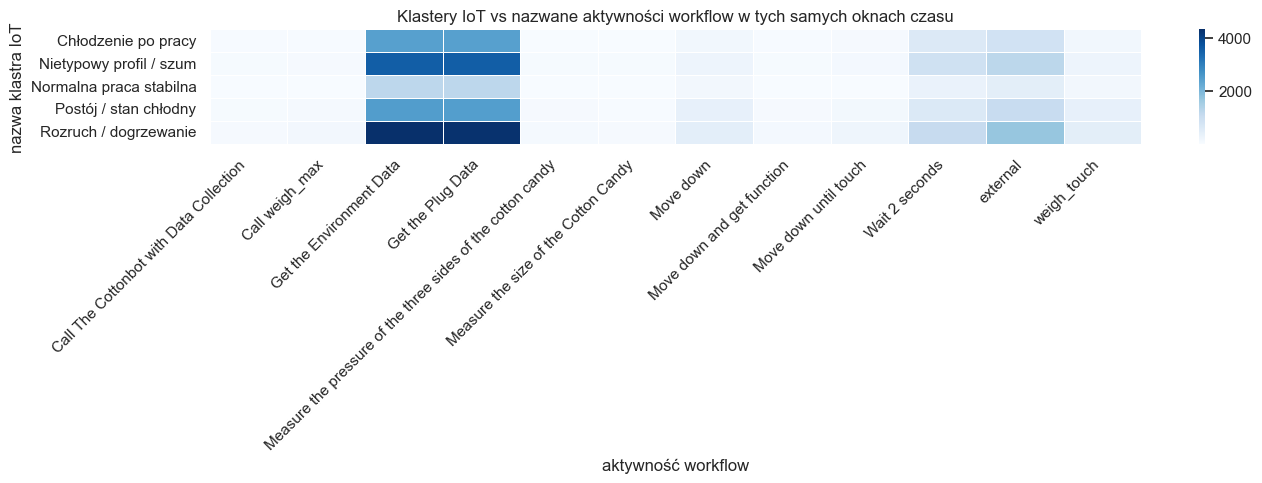

In [122]:
# Porównanie: klaster IoT vs aktywności workflow w tym samym oknie 5-minutowym.
workflow_window = df[["timestamp", "activity_clean", "case_id"]].dropna().copy()
workflow_window["time_window"] = workflow_window["timestamp"].dt.floor(WINDOW_SIZE)

cluster_window = df_sensor_windows_named[["time_window", "dbscan_cluster", "cluster_name"]].copy()
workflow_cluster = workflow_window.merge(cluster_window, on="time_window", how="inner")

if workflow_cluster.empty:
    print("Brak nakładania czasowego między workflow logiem i oknami sensorowymi.")
else:
    # Ograniczamy tabelę do najczęstszych aktywności, żeby wynik był czytelny.
    top_workflow_activities = workflow_cluster["activity_clean"].value_counts().head(12).index
    compare_df = workflow_cluster[workflow_cluster["activity_clean"].isin(top_workflow_activities)].copy()
    cluster_activity_matrix = pd.crosstab(
        compare_df["cluster_name"],
        compare_df["activity_clean"],
    )
    dominant_activity_per_cluster = (
        workflow_cluster.groupby(["dbscan_cluster", "cluster_name", "activity_clean"])
        .size()
        .reset_index(name="count")
        .sort_values(["dbscan_cluster", "count"], ascending=[True, False])
        .groupby(["dbscan_cluster", "cluster_name"])
        .head(5)
    )

    print("Macierz: nazwa klastra IoT x top aktywności workflow")
    display(cluster_activity_matrix)
    print("Top 5 aktywności workflow dla każdego klastra IoT")
    display(dominant_activity_per_cluster)

    cluster_activity_matrix.to_csv(REPORT_DIR / "m3_iot_clusters_vs_workflow_activities_matrix.csv")
    dominant_activity_per_cluster.to_csv(REPORT_DIR / "m3_iot_clusters_vs_workflow_activities_top.csv", index=False)

    plt.figure(figsize=(14, max(5, 0.45 * len(cluster_activity_matrix))))
    sns.heatmap(cluster_activity_matrix, cmap="Blues", linewidths=0.4)
    plt.title("Klastery IoT vs nazwane aktywności workflow w tych samych oknach czasu")
    plt.xlabel("aktywność workflow")
    plt.ylabel("nazwa klastra IoT")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "m3_iot_clusters_vs_workflow_activities.png", dpi=180, bbox_inches="tight")
    plt.show()

## 8. Porównanie modeli

### Model workflow logu

Model z workflow logu opisuje rzeczywiste kroki zapisane przez CPEE: pobieranie danych środowiskowych, pobieranie danych z wtyczki, oczekiwanie, ruchy robota, ważenie i zdarzenia systemowe. Najsilniejsze przejścia w DFG wskazują na pętle pomiarowe: `Get the Plug Data -> Get the Plug Data` oraz `Get the Environment Data -> Get the Environment Data`. Model ten jest szczegółowy i pokazuje architekturę procesu, ale jest też obciążony zdarzeniami technicznymi.

### Model z klastrów IoT

Model IoT nie używa nazw aktywności jako ground truth. Pokazuje fazy pracy maszyny wynikające z samych odczytów sensorów, np. postój, rozruch/dogrzewanie, intensywną pracę grzania, chłodzenie lub nietypowe profile. Ten model jest mniej szczegółowy proceduralnie, ale lepiej opisuje fizyczny stan urządzenia.

### Podobieństwa

- Oba modele wskazują cykliczny charakter procesu.
- W obu modelach widoczne są powtarzalne pętle: w workflow jako powtarzanie pomiarów, w IoT jako utrzymywanie się podobnych stanów maszyny w kolejnych oknach.
- Oba modele ujawniają miejsca nietypowe: rzadkie warianty i anomalie w workflow oraz szum DBSCAN w IoT.

### Różnice

- Workflow log opisuje logikę sterowania i wywołania usług, a IoT opisuje fizyczny profil pracy maszyny.
- Workflow ma nazwane aktywności, dlatego modele PM4Py są bardziej bezpośrednie. IoT wymaga interpretacji klastrów.
- Model workflow obejmuje pełny zbiór przypadków, natomiast dane sensorowe pochodzą z ograniczonej liczby plików `*-process.yaml`, więc model IoT traktujemy jako uzupełniający.

### Wnioski procesowe

- Największą część zachowania procesu tworzą pętle monitorowania sensorów i zasilania.
- Potencjalne wąskie gardła należy analizować przez czasy przejść oraz fazy z wysoką temperaturą głowicy i wysoką mocą.
- W finalnym BPMN warto uprościć zdarzenia techniczne i połączyć powtarzalne odczyty w podproces monitorowania.
- Model IoT może służyć jako warstwa diagnostyczna: wykrywa stan maszyny, którego nie widać bezpośrednio w samych nazwach aktywności.

In [123]:
# Zwięzłe podsumowanie artefaktów wygenerowanych przez notebook
artifacts = sorted(REPORT_DIR.glob("m3_*")) + sorted(FIG_DIR.glob("m3_*"))
print("Artefakty Milestone 3:")
for p in artifacts:
    print("-", p)

Artefakty Milestone 3:
- reports/milestone3/m3_iot_cluster_inductive_miner.bpmn
- reports/milestone3/m3_iot_cluster_names.csv
- reports/milestone3/m3_iot_cluster_transition_matrix.csv
- reports/milestone3/m3_iot_clustered_windows.csv
- reports/milestone3/m3_iot_clusters_vs_workflow_activities_matrix.csv
- reports/milestone3/m3_iot_clusters_vs_workflow_activities_top.csv
- reports/milestone3/m3_iot_dbscan_cluster_profiles.csv
- reports/milestone3/m3_iot_named_cluster_transitions.csv
- reports/milestone3/m3_resource_load.csv
- reports/milestone3/m3_workflow_alpha_miner.pnml
- reports/milestone3/m3_workflow_bottlenecks.csv
- reports/milestone3/m3_workflow_dfg_transitions.csv
- reports/milestone3/m3_workflow_inductive_miner.bpmn
- reports/milestone3/m3_workflow_transition_times.csv
- reports/milestone3/figures/m3_iot_cluster_inductive_miner.png
- reports/milestone3/figures/m3_iot_cluster_profiles_heatmap.png
- reports/milestone3/figures/m3_iot_cluster_transition_matrix.png
- reports/milest